This snippet handles data ingestion and initial column normalization:

* **Library Imports:** Loads fundamental libraries for numerical operations (`numpy`), data manipulation (`pandas`), visualization (`matplotlib`, `seaborn`), dataset access (`datasets`), and machine learning tools (`sklearn`).
* **Dataset Ingestion:** Downloads the customer segmentation dataset from Hugging Face and converts the `'train'` split into a Pandas DataFrame for analysis.
* **Column Cleanup:** Cleans all DataFrame column headers by removing leading and trailing whitespace to ensure consistent and bug-free referencing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. DATA LOADING & CLEANING
# Load customer segmentation dataset from Hugging Face and convert to DataFrame
ds = load_dataset("jason1966/abisheksudarshan_customer-segmentation")
df = ds['train'].to_pandas()

# Strip any leading/trailing whitespace from column names
df.columns = [c.strip() for c in df.columns]

c:\Users\aharu\Desktop\ACA\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This snippet performs Exploratory Data Analysis (EDA) using `seaborn` and `matplotlib` to analyze the target feature:

* **Plot Layout Setup:** Initializes a figure canvas with a specified width and height, splitting it into two side-by-side subplots.
* **Target Distribution:** Uses `sns.countplot` on the first subplot to show the frequency of each category within the `Spending_Score` column.
* **Feature Relationship Visualization:** Uses `sns.boxplot` on the second subplot to display the distribution of customer ages across different `Spending_Score` tiers.
* **Layout Formatting:** Applies `plt.tight_layout()` to prevent overlapping labels and renders the final visualizations.

C:\Users\aharu\AppData\Local\Temp\ipykernel_9120\1485024306.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Spending_Score', palette='Blues_d')
C:\Users\aharu\AppData\Local\Temp\ipykernel_9120\1485024306.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spending_Score', y='Age', palette='Set2')


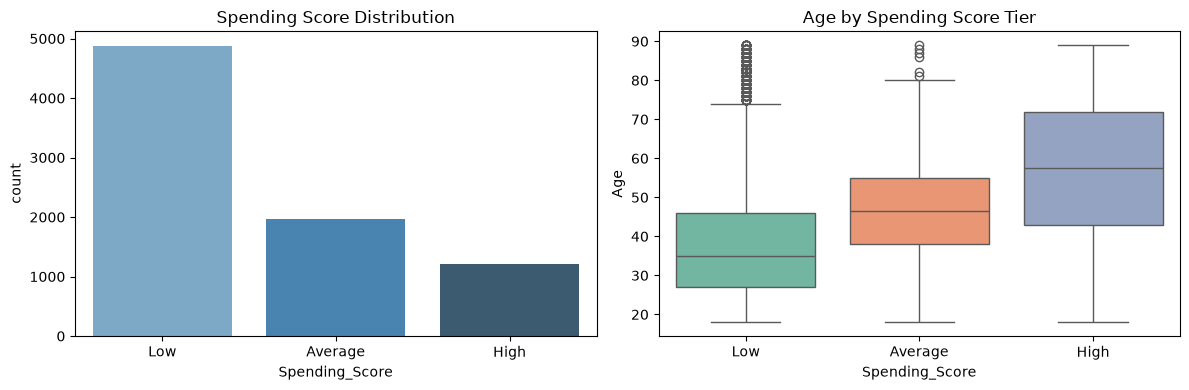

In [2]:

# 2. EXPLORATORY DATA ANALYSIS (EDA)
# Visualize target variable distribution and relationship with Age
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Spending_Score', palette='Blues_d')
plt.title('Spending Score Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Spending_Score', y='Age', palette='Set2')
plt.title('Age by Spending Score Tier')

plt.tight_layout()
plt.show()


This snippet analyzes the relationship between key categorical features and the target variable using grouped bar charts:

* **Subplot Grid Initialization:** Creates a row of three side-by-side subplots to display multiple categorical comparisons in a single figure.
* **Feature Categorization & Grouping:** Utilizes `sns.countplot` with the `hue='Spending_Score'` parameter to show how customer spending tiers break down across different `Profession`, `Ever_Married`, and `Graduated` status categories.
* **Axis & Layout Adjustment:** Rotates x-axis labels on the profession plot for readability and uses `plt.tight_layout()` to ensure clean visual spacing before rendering.

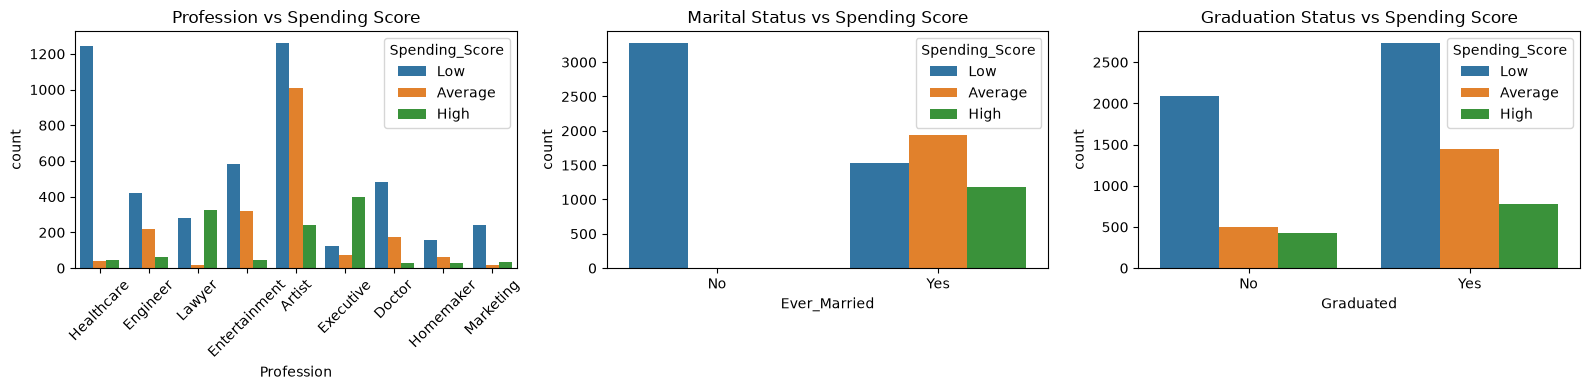

In [3]:

# Visualize relationships between categorical attributes and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='Profession', hue='Spending_Score', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Profession vs Spending Score')

sns.countplot(data=df, x='Ever_Married', hue='Spending_Score', ax=axes[1])
axes[1].set_title('Marital Status vs Spending Score')

sns.countplot(data=df, x='Graduated', hue='Spending_Score', ax=axes[2])
axes[2].set_title('Graduation Status vs Spending Score')

plt.tight_layout()
plt.show()


This snippet performs data cleaning, feature selection, feature engineering, and categorical encoding:

* **Missing Value Imputation:** Fills missing values in categorical columns (`Ever_Married`, `Graduated`, `Profession`) with the string `'Unknown'` and replaces missing numerical values in `Work_Experience` with the column's median.
* **Feature Selection:** Extracts a specific subset of relevant feature columns alongside the target variable into a clean DataFrame slice (`df_sub`).
* **Feature Engineering:** Derives new features—including ratio (`Experience_Age_Ratio`), binary indicator (`Is_Married`), interaction term (`Age_Married_Interact`), and string concatenation (`Graduated_Profession`)—to capture richer predictive relationships.
* **One-Hot Encoding:** Converts categorical variables into binary dummy columns using `pd.get_dummies()`, dropping the first category to prevent multicollinearity (dummy variable trap).

In [4]:

# 3. MISSING VALUE IMPUTATION
# Fill missing categorical values with 'Unknown' and numerical with median
df['Ever_Married'] = df['Ever_Married'].fillna('Unknown')
df['Graduated'] = df['Graduated'].fillna('Unknown')
df['Profession'] = df['Profession'].fillna('Unknown')
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())

# Select relevant subset of columns for modeling
cols = ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score']
df_sub = df[cols].copy()

# 4. FEATURE ENGINEERING
# Create interaction and ratio features to improve predictive signals
df_sub['Experience_Age_Ratio'] = df_sub['Work_Experience'] / df_sub['Age']
df_sub['Is_Married'] = (df_sub['Ever_Married'] == 'Yes').astype(int)
df_sub['Age_Married_Interact'] = df_sub['Age'] * df_sub['Is_Married']
df_sub['Graduated_Profession'] = df_sub['Graduated'] + "_" + df_sub['Profession']

# Convert categorical variables into one-hot dummy variables
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Graduated_Profession']
df_encoded = pd.get_dummies(df_sub, columns=categorical_cols, drop_first=True)


This snippet handles dataset partitioning and feature scaling for model preparation:

* **Feature-Target Separation:** Isolates the target variable `Spending_Score` into `y` and drops it from `df_encoded` to form the feature matrix `X`.
* **Stratified Data Splitting:** Uses `train_test_split()` to divide the dataset into an 80% training set and a 20% test set, using `stratify=y` to preserve the target class proportions in both splits.
* **Feature Standardization:** Applies `StandardScaler()` to center and scale selected continuous numerical features (`Age`, `Work_Experience`, `Experience_Age_Ratio`) to have zero mean and unit variance.
* **Data Leakage Prevention:** Fits the scaler exclusively on `X_train` data (`fit_transform`) and uses those learned parameters to transform `X_test` (`transform`), avoiding data leakage from the test set.

In [5]:

# 5. DATA SPLITTING & PREPROCESSING
# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Spending_Score'])
y = df_encoded['Spending_Score']

# Split data into stratified train and test sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize continuous numerical features
num_cols_to_scale = ['Age', 'Work_Experience', 'Experience_Age_Ratio']
scaler = StandardScaler()

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

This snippet trains the machine learning model, generates predictions, and evaluates its performance:

* **Model Initialization & Training:** Instantiates a `RandomForestClassifier` configured with 150 decision trees and a maximum tree depth of 10, then fits the model on the training set (`X_train`, `y_train`).
* **Prediction Generation:** Uses the trained model (`clf`) to predict target labels for the held-out test feature matrix (`X_test`).
* **Classification Performance Metrics:** Prints a `classification_report()` containing precision, recall, F1-score, and accuracy metrics for each `Spending_Score` class.
* **Confusion Matrix Visualization:** Computes a confusion matrix comparing actual test labels (`y_test`) against predicted values (`y_pred`), and renders it as an annotated heatmap using `seaborn` to show true vs. false predictions across all spending classes.


--- Classification Report ---
              precision    recall  f1-score   support

     Average       0.57      0.88      0.69       395
        High       0.66      0.55      0.60       243
         Low       0.92      0.75      0.83       976

    accuracy                           0.76      1614
   macro avg       0.72      0.73      0.71      1614
weighted avg       0.80      0.76      0.76      1614



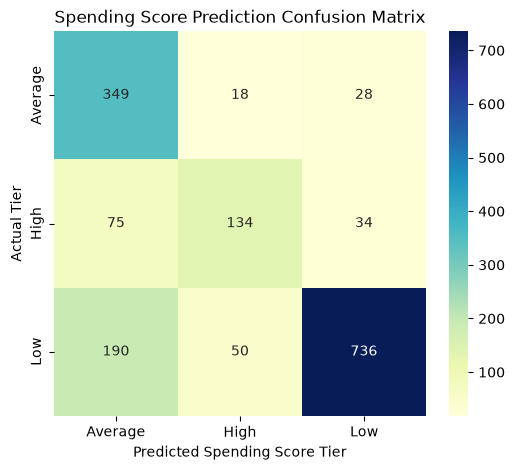

In [6]:

# 6. MODEL TRAINING
# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# 7. MODEL EVALUATION
# Predict on test set and print performance metrics
y_pred = clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
labels = sorted(y.unique())
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=labels), 
            annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Spending Score Tier')
plt.ylabel('Actual Tier')
plt.title('Spending Score Prediction Confusion Matrix')
plt.show()

This snippet extracts, ranks, and visualizes the top feature importances from the trained model:

* **Feature Importance Extraction:** Computes Gini importances from the fitted `RandomForestClassifier` (`clf.feature_importances_`), maps them to feature names, and sorts them in descending order using `pd.Series`.
* **Bar Chart Visualization:** Plots the top 10 most influential features as a horizontal bar chart (`kind='barh'`) with a custom teal color palette.
* **Layout Formatting:** Inverts the y-axis (`invert_yaxis()`) to display the highest importance feature at the top of the chart and labels the x-axis with "Gini Importance".

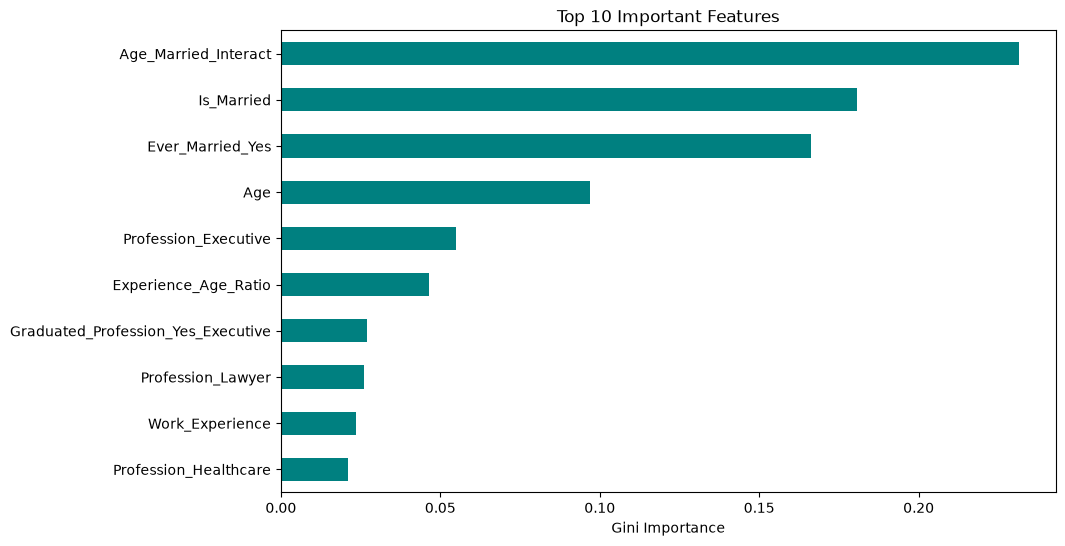

In [7]:

# 8. FEATURE IMPORTANCE ANALYSIS
# Extract and plot top 10 most influential features
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features')
plt.xlabel('Gini Importance')
plt.show()